### Functional annotation of CF viruses

In [1]:
### Load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [2]:
### Identify viruses detected in CF metagenomes
activity_data = (
    pl.read_csv('cf_metagenome_virus_activity_data.tsv', separator='\t')
        .filter(pl.col('breadth_ratio') >= 0.6)
)

In [42]:
### Identify ARGs using alignment to CARD
card_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/card/diamond/*.fna/*.fna.card.tsv.gz"
card_lst = []
for file in glob.glob(card_dir):
    try:
        df = pl.read_csv(file, separator='\t', has_header=False, columns=[0, 1])
        card_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

card_df = (
    pl.concat(card_lst)
        .with_columns([pl.col('column_1').str.replace(r"_[^_]*$", "")])
        .with_columns([pl.col('column_1').str.replace('uhvdb_votu_reps.fna_', '')])
        .join(activity_data, left_on='column_1', right_on='contig_id', how='inner')
        .group_by(['column_1', 'sample_id', 'activity_score'])
        .len()
)
print(f"Total genomes with CARD hits: {card_df.height}")

Total genomes with CARD hits: 60


In [43]:
### Identify VFs using alignment to VFDB
### VFDB
vfdb_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/vfdb/diamond/*.fna/*.fna.vfdb.tsv.gz"
vfdb_lst = []
for file in glob.glob(vfdb_dir):
    try:
        df = pl.read_csv(file, separator='\t', has_header=False, columns=[0, 1])
        vfdb_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

vfdb_df = (
    pl.concat(vfdb_lst)
    .with_columns([pl.col('column_1').str.replace(r"_[^_]*$", "")])
    .with_columns([pl.col('column_1').str.replace('uhvdb_votu_reps.fna_', '')])
    .join(activity_data, left_on='column_1', right_on='contig_id', how='inner')
    .group_by(['column_1', 'sample_id', 'activity_score'])
    .len()
)
print(f"Total genomes with VFDB hits: {vfdb_df.height}")

Total genomes with VFDB hits: 2147


In [44]:
### Count defense systems identified via defense finder
df_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/defensefinder/run/*.fna/*systems.tsv.gz"
df_lst = []
for file in glob.glob(df_dir):
    try:
        df = pl.read_csv(file, separator='\t', ignore_errors=True, columns=['sys_id', 'type', 'activity', 'protein_in_syst'])
        df_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

df_df = (
    pl.concat(df_lst)
        .filter(pl.col('activity') == 'Defense')
        .with_columns([pl.col('protein_in_syst').str.split(',').list[0].str.replace(r"_[^_]*$", "")])
        .with_columns([pl.col('protein_in_syst').str.replace('uhvdb_votu_reps.fna_', '')])
        .join(activity_data, left_on='protein_in_syst', right_on='contig_id', how='inner')
        .group_by(['protein_in_syst', 'sample_id', 'activity_score'])
        .len()
)
print(f"Total Defense Finder genomes: {df_df.height}")

Total Defense Finder genomes: 6169


In [45]:
### Count defense systems identified via padloc
padloc_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/padloc/padloc/*.fna/*padloc.csv.gz"
padloc_lst = []
for file in glob.glob(padloc_dir):
    try:
        df = pl.read_csv(file, ignore_errors=True, columns=['seqid', 'system'])
        padloc_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

padloc_df = (
    pl.concat(padloc_lst)
    .with_columns([pl.col('seqid').str.replace('uhvdb_votu_reps.fna_', '')])
    .join(activity_data, left_on='seqid', right_on='contig_id', how='inner')
    .group_by(['seqid', 'sample_id', 'activity_score'])
    .len()
)
print(f"Total Padloc genomes: {padloc_df.height}")

Total Padloc genomes: 8790


In [46]:
antidf_df = (
    pl.concat(df_lst)
        .filter(pl.col('activity') == 'Antidefense')
        .with_columns([pl.col('protein_in_syst').str.split(',').list[0].str.replace(r"_[^_]*$", "")])
        .with_columns([pl.col('protein_in_syst').str.replace('uhvdb_votu_reps.fna_', '')])
        .join(activity_data, left_on='protein_in_syst', right_on='contig_id', how='inner')
        .group_by(['protein_in_syst', 'sample_id', 'activity_score'])
        .len()
)
print(f"Total Anti-Defense Finder genomes: {antidf_df.height}")

Total Anti-Defense Finder genomes: 5302


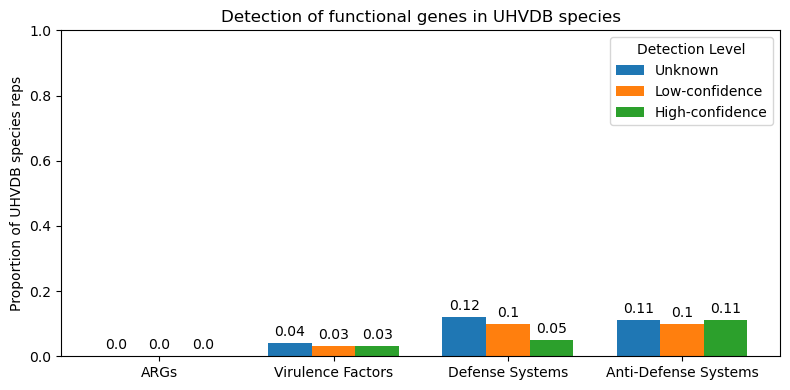

In [54]:
### ARG, CF, Defense, AntiDefense
total_genomes = activity_data.unique(['contig_id', 'sample_id']).height
lc_genomes = activity_data.filter(pl.col('activity_score') >= 1).unique(['contig_id', 'sample_id']).height
hc_genomes = activity_data.filter(pl.col('activity_score') >= 3).unique(['contig_id', 'sample_id']).height

# round to 2 decimals
arg_unk = round(card_df.height/total_genomes, 2)
arg_lc = round(card_df.filter(pl.col('activity_score') >= 1).height/lc_genomes, 2)
arg_hc = round(card_df.filter(pl.col('activity_score') >= 3).height/hc_genomes, 2)

vf_unk = round(vfdb_df.height/total_genomes, 2)
vf_lc = round(vfdb_df.filter(pl.col('activity_score') >= 1).height/lc_genomes, 2)
vf_hc = round(vfdb_df.filter(pl.col('activity_score') >= 3).height/hc_genomes, 2)

defense_unk = round(df_df.height/total_genomes, 2)
defense_lc = round(df_df.filter(pl.col('activity_score') >= 1).height/lc_genomes, 2)
defense_hc = round(df_df.filter(pl.col('activity_score') >= 3).height/hc_genomes, 2)

antidefense_unk = round(antidf_df.height/total_genomes, 2)
antidefense_lc = round(antidf_df.filter(pl.col('activity_score') >= 1).height/lc_genomes, 2)
antidefense_hc = round(antidf_df.filter(pl.col('activity_score') >= 3).height/hc_genomes, 2)

# plot bar chart
labels = ['ARGs', 'Virulence Factors', 'Defense Systems', 'Anti-Defense Systems']
unk_counts = [arg_unk, vf_unk, defense_unk, antidefense_unk]
lc_counts = [arg_lc, vf_lc, defense_lc, antidefense_lc]
hc_counts = [arg_hc, vf_hc, defense_hc, antidefense_hc]
x = range(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette()[:3]
bars1 = ax.bar([i - width for i in x], unk_counts, width, label='Unknown', color=colors[0])
bars2 = ax.bar(x, lc_counts, width, label='Low-confidence', color=colors[1])
bars3 = ax.bar([i + width for i in x], hc_counts, width, label='High-confidence', color=colors[2])
ax.set_ylabel('Proportion of UHVDB species reps')
plt.ylim(0,1)
ax.set_title('Detection of functional genes in UHVDB species')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(title='Detection Level')
for bar in bars1 + bars2 + bars3:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')
plt.tight_layout()
plt.show()